# Part 6a: Stochastic continuous-time dynamical systems (SDEs)

We introduce **continuous-time** state evolution via **ContinuousTimeStateEvolution** and the **SDESimulator**, and run inference with **filtering** (e.g. EnKF) on a partially observed Lorenz 63 example.

## 6.1 ContinuousTimeStateEvolution: drift, diffusion, and SDEs

In continuous time, the state evolves according to an **Itô SDE**:

$$dX_t = f(X_t, u_t, t)\,dt + L(X_t, u_t, t)\,dW_t$$

where $W_t$ is a vector Brownian motion. We specify:

- **`drift`**: $f(x, u, t)$ — the deterministic part (vector of same dimension as state).
- **`diffusion_coefficient`**: $L(x, u, t)$ — matrix such that the diffusion term is $L\,dW_t$. Shape is `(state_dim, brownian_dim)`.

All three are callables with signature `(x, u, t)`: state `x`, control `u` (or `None`), and time `t`.

## 6.2 Generating data: SDESimulator

To **simulate** a continuous-time model we use **`SDESimulator`** (instead of `DiscreteTimeSimulator`). It integrates the SDE and observes at the given times. We pass `obs_times` directly to the model.

## 6.3 Lorenz 63 with partial observations

Lorenz 63 has state $x = (x_1, x_2, x_3)$ and drift

$$f(x) = \big(\sigma(x_2 - x_1),\, x_1(\rho - x_3) - x_2,\, x_1 x_2 - \beta x_3\big).$$

We take $\sigma=10$, $\beta=8/3$, and sample $\rho$ from a prior. We observe **only the first component** $x_1$ with Gaussian noise: $y_t = H x_t + \varepsilon_t$ with $H = [1, 0, 0]$ and $R = 1^2$. This is **partial observation** and is specified via **`LinearGaussianObservation(H, R)`**. The matrix $H$ has shape `(observation_dim, state_dim)`; here we use `H = [[1, 0, 0]]` so we get one scalar observation per time. Using `LinearGaussianObservation` gives access to **structured inference** methods (EnKF, EKF, UKF) in CD-Dynamax; for more general observation models or non-Gaussian initial conditions, particle filters (e.g. DPF) are available.

In [2]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
    SDESimulator,
)

state_dim = 3
observation_dim = 1


def l63_model(obs_times=None, obs_values=None, predict_times=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim), covariance_matrix=20.0**2 * jnp.eye(state_dim)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion_coefficient=lambda x, u, t: jnp.eye(3),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(observation_dim, state_dim),  # observe only x[0]
            R=jnp.eye(observation_dim),
        ),
    )
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

In [3]:
key = jr.PRNGKey(0)
rho_true = 28.0
T_forecast = 8.0
# Generate longer trajectory: training window + held-out future for rollout evaluation
obs_times_full = jnp.arange(0.0, 20.0 + T_forecast, 0.01)  # 0..28

predictive = Predictive(
    l63_model,
    params={"rho": jnp.array(rho_true)},
    num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator():
    synthetic = predictive(key, predict_times=obs_times_full)

# With num_samples=1, leading dim may be present
times = (
    jnp.squeeze(synthetic["f_times"], axis=0)
    if synthetic["f_times"].ndim == 2
    else synthetic["f_times"]
)
states = synthetic["f_states"][0]  # (T, 3)
observations = synthetic["f_observations"][0]  # (T, 1)

# Training portion (0..20) for MCMC; future (20..28) withheld for rollout eval
mask_train_full = times <= 20.0
times_train_full = times[mask_train_full]
observations_train = observations[mask_train_full]

times_test_full = times[~mask_train_full]
observations_test_full = observations[~mask_train_full]

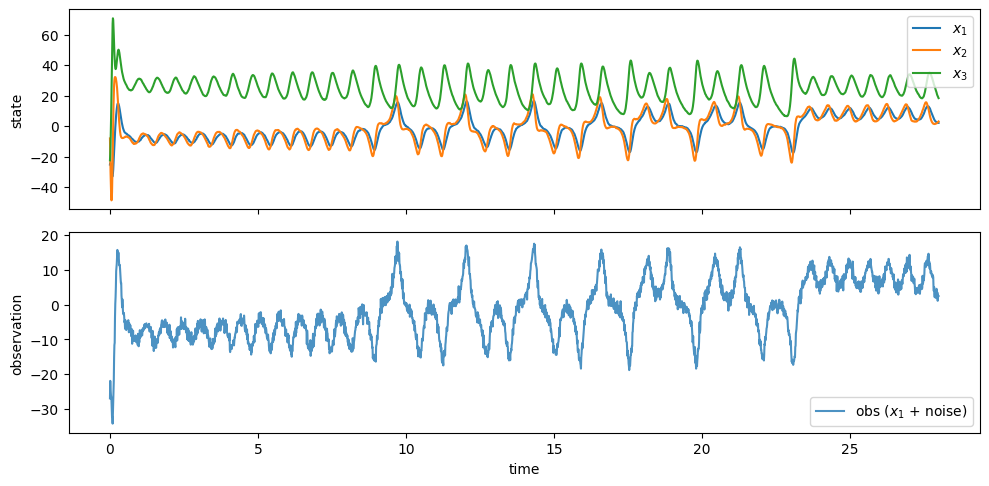

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(times, states[:, 0], label="$x_1$")
axes[0].plot(times, states[:, 1], label="$x_2$")
axes[0].plot(times, states[:, 2], label="$x_3$")
axes[0].set_ylabel("state")
axes[0].legend(loc="upper right")
axes[1].plot(
    times, observations[:, 0], label="obs ($x_1$ + noise)", color="C0", alpha=0.8
)
axes[1].set_ylabel("observation")
axes[1].set_xlabel("time")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6.4 Inference: NUTS + Filtering (EnKF)

For continuous-time models we use **Filter** with a filter supported by CD-Dynamax. The **default** (and a good choice for nonlinear models) is the **EnKF** (ensemble Kalman filter). Other options include **EKF** and **UKF** (both Gaussian approximations), and **DPF** (differentiable particle filter) for non-Gaussian observation models or initial conditions.

We pass the observed values `obs_values` along with `obs_times` to the model for inference.

In [5]:
from numpyro.infer import MCMC, NUTS

from dynestyx import Filter
from dynestyx.inference.filters import ContinuousTimeEnKFConfig

with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=50)):
    nuts_kernel = NUTS(l63_model)
    mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
    mcmc.run(jr.PRNGKey(1), obs_times=times_train_full, obs_values=observations_train)
posterior = mcmc.get_samples()
print("Posterior rho mean:", float(jnp.mean(posterior["rho"])))
print("True rho:", rho_true)

sample: 100%|██████████| 200/200 [02:44<00:00,  1.22it/s, 1 steps of size 9.13e-01. acc. prob=0.94] 

Posterior rho mean: 28.155649185180664
True rho: 28.0


## 6.6 Rollout: Filter + Simulator with `predict_times`

To evaluate **rollout quality**—especially forecasts into the future—use **Filter + SDESimulator** with `predict_times`. Use a dense time grid from `obs_times[0]` to `obs_times[-1] + T` to show fitting between sparse data points (relevant for continuous time) and rollout past the final filtered time. The filter conditions on observations; the simulator rolls out trajectories at `predict_times`, producing `f_predicted_states` and `f_predicted_observations`. With `n_simulations > 1`, you get multiple trajectories for uncertainty bands.

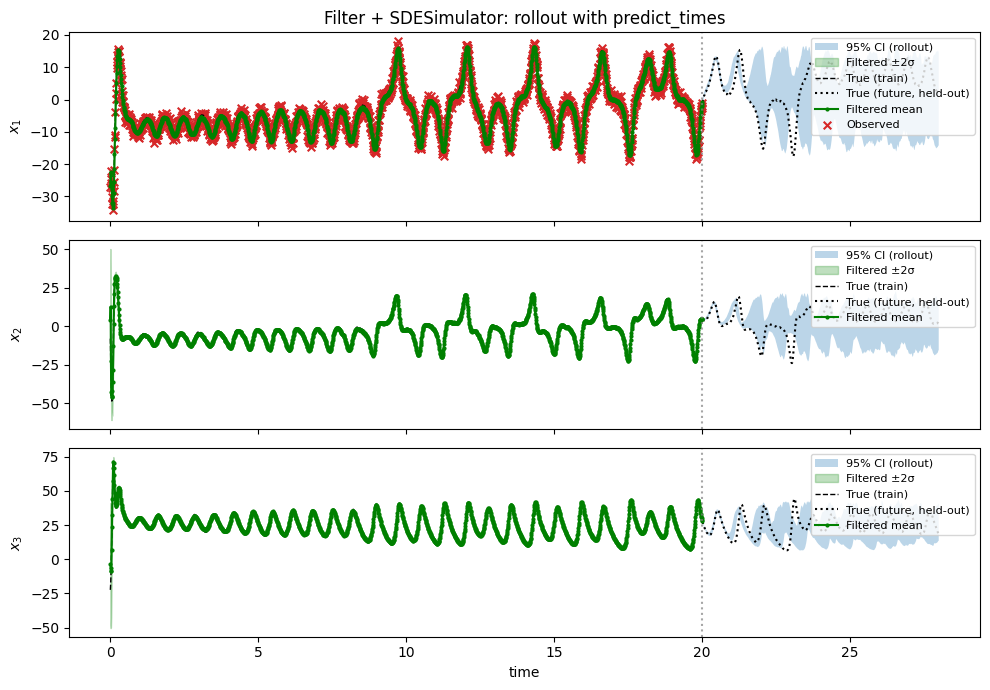

In [6]:
rho_post_mean = jnp.mean(posterior["rho"])
n_sim = 30

predictive = Predictive(
    l63_model,
    params={"rho": jnp.array(rho_post_mean)},
    num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator(n_simulations=n_sim):
    with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=50, record_filtered_states_mean=True, record_filtered_states_cov_diag=True)):
        samples = predictive(
            jr.PRNGKey(99),
            obs_times=times_train_full,
            obs_values=observations_train,
            predict_times=times_test_full,
        )

pred_states = samples["f_predicted_states"].squeeze(0)  # (n_sim, T_pred, 3)
pred_times_arr = samples["f_predicted_times"]
if pred_times_arr.ndim > 1:
    pred_times_arr = pred_times_arr.squeeze(0)
filtered_means = samples["f_filtered_states_mean"].squeeze(0)  # (T_train, 3)
filtered_cov_diag = samples["f_filtered_states_cov_diag"].squeeze(0)  # (T_train, 3)
filtered_std = jnp.sqrt(filtered_cov_diag)

# Plot: true states, filtered means, observations, predicted CI
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
lo = jnp.percentile(pred_states, 2.5, axis=0)
hi = jnp.percentile(pred_states, 97.5, axis=0)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for i, ax in enumerate(axes):
    ax.fill_between(pred_times_arr, lo[:, i], hi[:, i], alpha=0.3, label="95% CI (rollout)")
    ax.fill_between(times_train_full, filtered_means[:, i] - 2 * filtered_std[:, i], filtered_means[:, i] + 2 * filtered_std[:, i], alpha=0.25, color="green", label="Filtered ±2σ")
    ax.plot(times_train_full, states[mask_train_full][:, i], "k--", label="True (train)", lw=1)
    ax.plot(times_test_full, states[~mask_train_full][:, i], "k:", lw=1.5, label="True (future, held-out)")
    ax.plot(times_train_full, filtered_means[:, i], "g.-", markersize=4, label="Filtered mean")
    if i == 0:
        ax.scatter(times_train_full, observations[mask_train_full][:, 0], color="C3", marker="x", s=30, label="Observed")
        # ax.scatter(times_test_full, observations[~mask_train_full][:, 0], color="C4", marker="+", s=30, label="Future (held-out)")
    ax.set_ylabel(state_labels[i])
    ax.legend(loc="upper right", fontsize=8)
    ax.axvline(times_train_full[-1], color="gray", linestyle=":", alpha=0.7)
axes[0].set_title("Filter + SDESimulator: rollout with predict_times")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

## 6.7 Back-tested real-time forecasting: sparse observations, dense predictions

We generate a **new** synthetic dataset and apply the learned model in a "real-time" scenario: observations arrive at sparse times (e.g., every 50th timepoint), and we produce dense posterior-predictive trajectories by setting `predict_times` to a finer grid than `obs_times`. The filter conditions only on past and current observations; the simulator predicts at the dense times, effectively **interpolating** between sparse data points. This back-test mimics online forecasting where we would not have future data.

**Note:** A **smoother** (which uses future observations to refine past estimates) would yield more accurate interpolations than a filter, since it can leverage information from both past and future. Here we use filtering to reflect the causal, real-time setting.

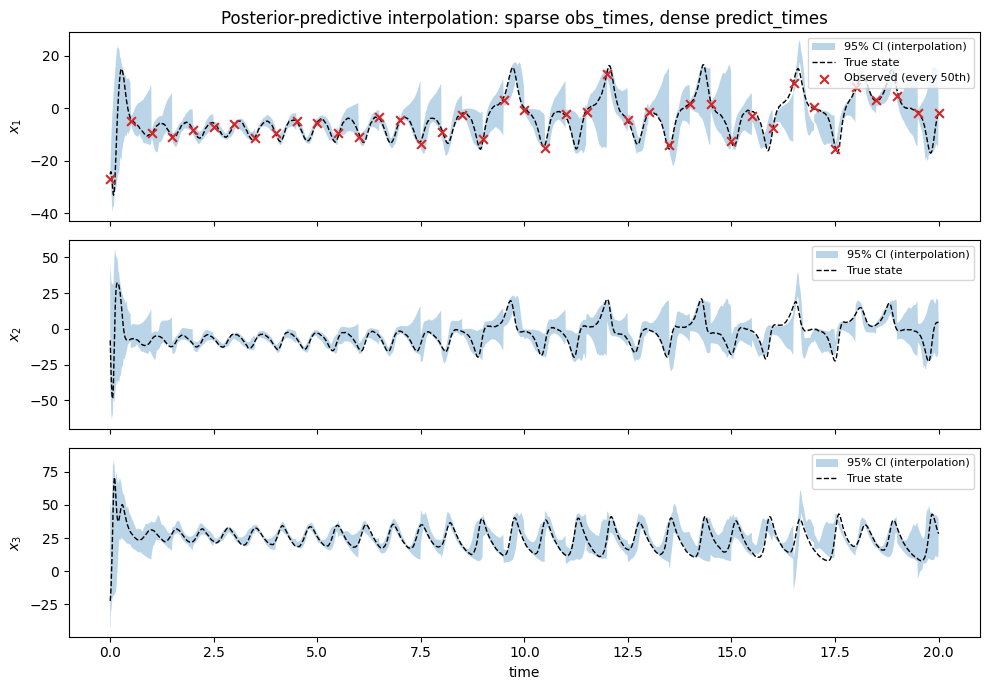

In [8]:
# Generate a NEW dataset for back-testing (different trajectory)
key_backtest = jr.PRNGKey(123)
times_backtest = jnp.arange(0.0, 15.0, 0.01)  # shorter window for demo
with SDESimulator():
    synthetic_backtest = Predictive(
        l63_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )(key_backtest, predict_times=times_backtest)
states_backtest = synthetic_backtest["f_states"][0]
observations_backtest = synthetic_backtest["f_observations"][0]
if synthetic_backtest["f_times"].ndim > 1:
    times_backtest = synthetic_backtest["f_times"].squeeze(0)

# Sparse observations: every 50th timepoint (as would arrive in real time)
downsample = 50
obs_times_sparse = times_backtest[::downsample]
obs_values_sparse = observations_backtest[::downsample]

# Dense predict_times: full grid (interpolation between sparse obs)
predict_times_dense = times_backtest

# Apply learned model: posterior-predictive with Filter + SDESimulator
predictive_interp = Predictive(
    l63_model,
    params={"rho": jnp.array(rho_post_mean)},
    num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator(n_simulations=50):
    with Filter(
        filter_config=ContinuousTimeEnKFConfig(
            n_particles=50,
            record_filtered_states_mean=True,
            record_filtered_states_cov_diag=True,
        )
    ):
        samples_interp = predictive_interp(
            jr.PRNGKey(42),
            obs_times=obs_times_sparse,
            obs_values=obs_values_sparse,
            predict_times=predict_times_dense,
        )

pred_states_interp = samples_interp["f_predicted_states"].squeeze(0)  # (n_sim, T_dense, 3)
pred_times_interp = samples_interp["f_predicted_times"]
if pred_times_interp.ndim > 1:
    pred_times_interp = pred_times_interp.squeeze(0)

# Plot: sparse observations (scatter) vs dense posterior-predictive interpolation (bands)
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
lo = jnp.percentile(pred_states_interp, 2.5, axis=0)
hi = jnp.percentile(pred_states_interp, 97.5, axis=0)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for i, ax in enumerate(axes):
    ax.fill_between(
        pred_times_interp, lo[:, i], hi[:, i], alpha=0.3, label="95% CI (interpolation)"
    )
    ax.plot(
        times_backtest,
        states_backtest[:, i],
        "k--",
        label="True state",
        lw=1,
    )
    if i == 0:
        ax.scatter(
            obs_times_sparse,
            obs_values_sparse[:, 0],
            color="C3",
            marker="x",
            s=40,
            zorder=5,
            label=f"Observed (every {downsample}th)",
        )
    ax.set_ylabel(state_labels[i])
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title(
    "Back-tested real-time forecasting: sparse obs, dense predict_times"
)
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

## 6.5 Full observations and high-frequency, low-noise data

A common special case is **full observations** with **high-frequency, low-noise** measurements. Under that assumption we can **accelerate inference** dramatically at the expense of some bias (depending on how valid the assumption is). See the [deep dive on this topic](../../../deep_dives/l63_speedup_dirac_vs_enkf/) for details.

**Next:** [Part 6b — ODEs](../06b_odes/)